In [1]:
import torch

In [2]:
torch.__version__

'2.3.1+cu121'

In [3]:
torch.cuda.is_available()

True

In [4]:
! set CUDA_HOME="C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\\v12.1"
! set AM_I_DOCKER=False
! set BUILD_WITH_CUDA=True

In [5]:
import os, sys

sys.path.append(os.path.join(os.getcwd(), "GroundingDINO"))

In [6]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [7]:
import argparse
import os
import copy

import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
from torchvision.ops import box_convert

# Grounding DINO
import GroundingDINO.groundingdino.datasets.transforms as T
from GroundingDINO.groundingdino.models import build_model
from GroundingDINO.groundingdino.util import box_ops
from GroundingDINO.groundingdino.util.slconfig import SLConfig
from GroundingDINO.groundingdino.util.utils import clean_state_dict, get_phrases_from_posmap
from GroundingDINO.groundingdino.util.inference import annotate, load_image, predict

import supervision as sv

# segment anything
base_path = r"C:\\Users\\test\\kwangwoon\\2024_1\\산학연계\\image_searching\segment-anything"

# 경로를 sys.path에 추가
if base_path not in sys.path:
    sys.path.append(base_path)

from segment_anything import build_sam, SamPredictor 
import cv2
import numpy as np
import matplotlib.pyplot as plt


# diffusers
import PIL
import requests
import torch
from io import BytesIO
from diffusers import StableDiffusionInpaintPipeline


from huggingface_hub import hf_hub_download

c:\Users\test\.conda\envs\designovel2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
def load_model_hf(repo_id, filename, ckpt_config_filename, device='cpu'):
    cache_config_file = hf_hub_download(repo_id=repo_id, filename=ckpt_config_filename)

    args = SLConfig.fromfile(cache_config_file) 
    model = build_model(args)
    args.device = device

    cache_file = hf_hub_download(repo_id=repo_id, filename=filename)
    checkpoint = torch.load(cache_file, map_location='cpu')
    log = model.load_state_dict(clean_state_dict(checkpoint['model']), strict=False)
    print("Model loaded from {} \n => {}".format(cache_file, log))
    _ = model.eval()
    return model  

In [9]:
# Use this command for evaluate the Grounding DINO model
# Or you can download the model by yourself
ckpt_repo_id = "ShilongLiu/GroundingDINO"
ckpt_filenmae = "groundingdino_swinb_cogcoor.pth"
ckpt_config_filename = "GroundingDINO_SwinB.cfg.py"

In [10]:
groundingdino_model = load_model_hf(ckpt_repo_id, ckpt_filenmae, ckpt_config_filename)

final text_encoder_type: bert-base-uncased
Model loaded from C:\Users\test\.cache\huggingface\hub\models--ShilongLiu--GroundingDINO\snapshots\a94c9b567a2a374598f05c584e96798a170c56fb\groundingdino_swinb_cogcoor.pth 
 => _IncompatibleKeys(missing_keys=[], unexpected_keys=['label_enc.weight', 'bert.embeddings.position_ids'])


In [11]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(DEVICE)
sam_checkpoint = 'sam_vit_h_4b8939.pth'
sam = build_sam(checkpoint=sam_checkpoint)
sam.to(device=DEVICE)
sam_predictor = SamPredictor(sam)

cuda:0


In [12]:
# import io


# def download_image(url, image_file_path):
#     r = requests.get(url, timeout=4.0)
#     if r.status_code != requests.codes.ok:
#         assert False, 'Status code error: {}.'.format(r.status_code)

#     with Image.open(io.BytesIO(r.content)) as im:
#         im.save(image_file_path)

#     print('Image downloaded from url: {} and saved to: {}.'.format(url, image_file_path))

# # download_image(image_url, local_image_path)

In [25]:
# local_image_path = 'assets/시티보이 빅 오버핏 빅사이즈 쿨 린넨 셔츠 5 COLOR.jpg'
local_image_path = 'assets/handsome_test1.webp'

In [26]:
TEXT_PROMPT = "casual pants"
BOX_TRESHOLD = 0.3
TEXT_TRESHOLD = 0.25

image_source, image = load_image(local_image_path)

boxes, logits, phrases = predict(
    model=groundingdino_model, 
    image=image, 
    caption=TEXT_PROMPT, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD,
    device=DEVICE
)

annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)
annotated_frame = annotated_frame[...,::-1] # BGR to RGB

<PIL.Image.Image image mode=RGB size=684x1032 at 0x1F2EC3C0CA0>
Adjusted topk value: 900


SupervisionWarnings: annotate is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


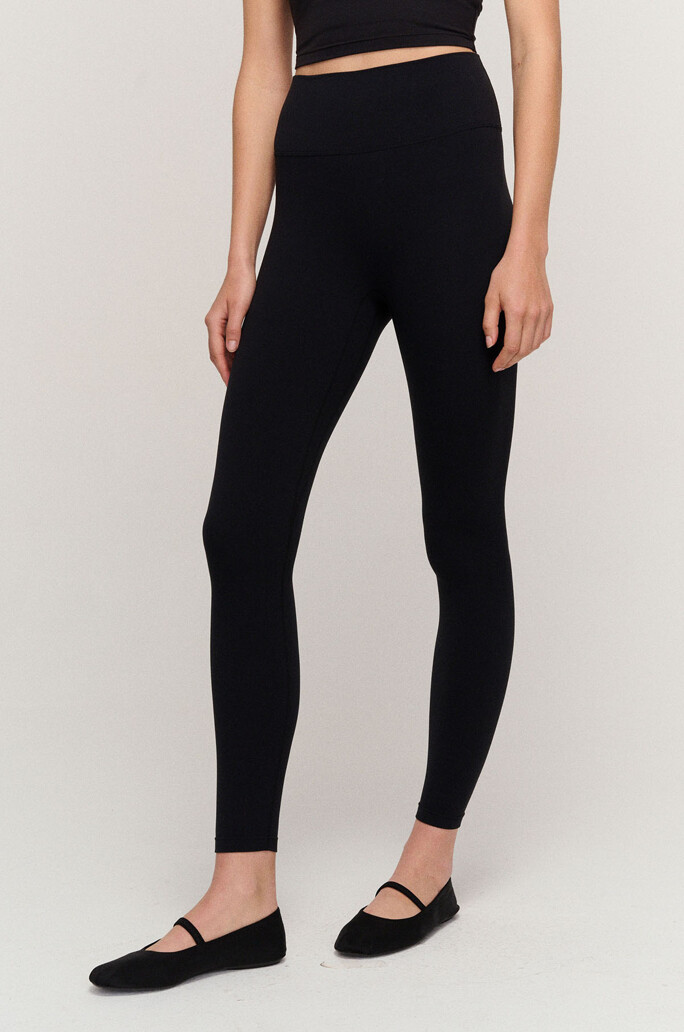

In [27]:
Image.fromarray(image_source)

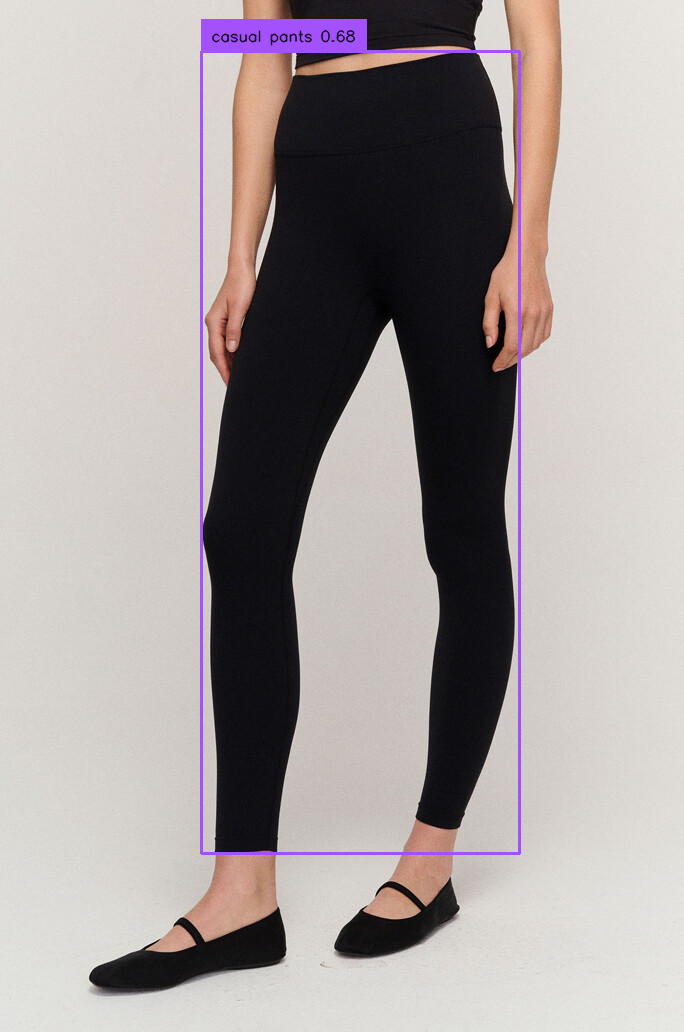

In [28]:
Image.fromarray(annotated_frame)

In [29]:
# set image
sam_predictor.set_image(image_source)

In [30]:
# box: normalized box xywh -> unnormalized xyxy
H, W, _ = image_source.shape
boxes_xyxy = box_ops.box_cxcywh_to_xyxy(boxes) * torch.Tensor([W, H, W, H])

In [31]:
transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_xyxy, image_source.shape[:2]).to(DEVICE)
masks, _, _ = sam_predictor.predict_torch(
            point_coords = None,
            point_labels = None,
            boxes = transformed_boxes,
            multimask_output = False,
        )

In [19]:
import numpy as np
from PIL import Image

def show_mask(mask, image, random_color=True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.8])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    
    h, w = mask.shape[-2:]
    mask_image = mask.cpu().reshape(h, w, 1).numpy() * color.reshape(1, 1, -1)
    
    annotated_frame_pil = Image.fromarray(image).convert("RGBA")
    mask_image_pil = Image.fromarray((mask_image * 255).astype(np.uint8)).convert("RGBA")

    return np.array(Image.alpha_composite(annotated_frame_pil, mask_image_pil))


In [20]:
annotated_frame_with_mask = show_mask(masks[0][0], annotated_frame)

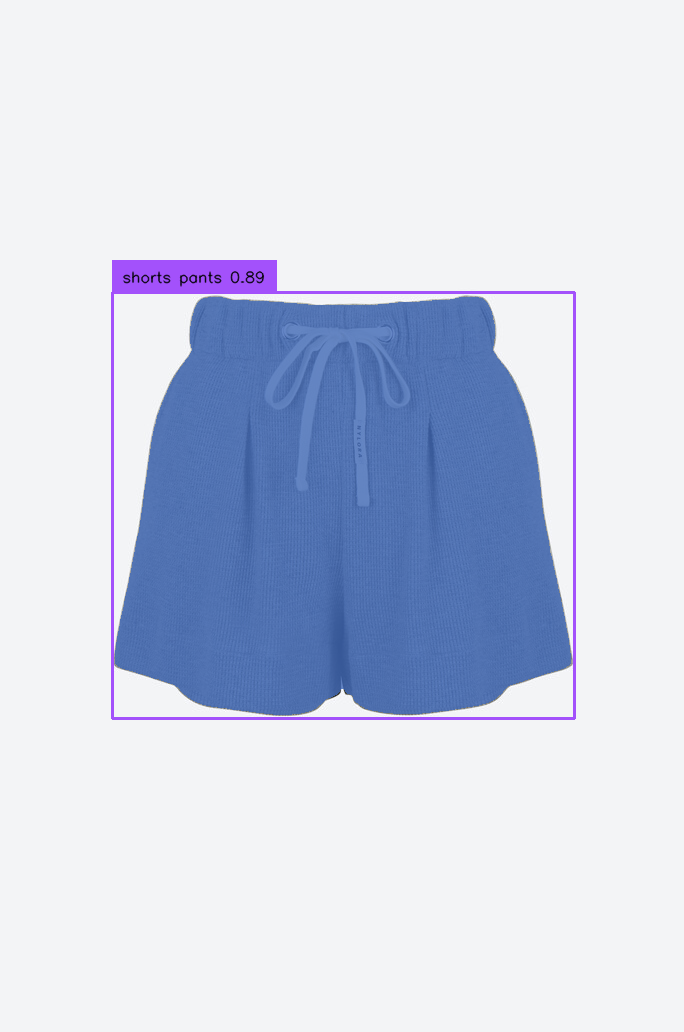

In [21]:
Image.fromarray(annotated_frame_with_mask)

In [22]:
def segment(image, sam_model, boxes):
  sam_model.set_image(image)
  H, W, _ = image.shape
  boxes_xyxy = box_ops.box_cxcywh_to_xyxy(boxes) * torch.Tensor([W, H, W, H])

  transformed_boxes = sam_model.transform.apply_boxes_torch(boxes_xyxy.to(DEVICE), image.shape[:2])
  masks, _, _ = sam_model.predict_torch(
      point_coords = None,
      point_labels = None,
      boxes = transformed_boxes,
      multimask_output = False,
      )
  return masks.cpu()


def draw_mask(mask, image, random_color=True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.8])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)

    annotated_frame_pil = Image.fromarray(image).convert("RGBA")
    mask_image_pil = Image.fromarray((mask_image.cpu().numpy() * 255).astype(np.uint8)).convert("RGBA")

    return np.array(Image.alpha_composite(annotated_frame_pil, mask_image_pil))

In [23]:
# def apply_mask_to_image(image, mask):
#     # 마스크된 부분만을 원본 이미지에 적용합니다.
#     masked_image = image.copy()
#     masked_image[mask == 0] = [255, 255, 255]
#     return masked_image

def apply_mask_to_image(image, mask):
    # 마스크된 부분만을 원본 이미지에 적용합니다.
    masked_image = image.copy()
    masked_image[mask == 0] = [255, 255, 255]

    masked_indices = np.where(mask != 0)

    # 마스크된 부분의 최소 및 최대 y, x 좌표를 찾습니다.
    min_y, min_x = np.min(masked_indices, axis=1)
    max_y, max_x = np.max(masked_indices, axis=1)

    # 마스크된 부분만을 포함하는 새로운 이미지 생성
    masked_region_only = masked_image[min_y:max_y+1, min_x:max_x+1, :]

    return masked_region_only


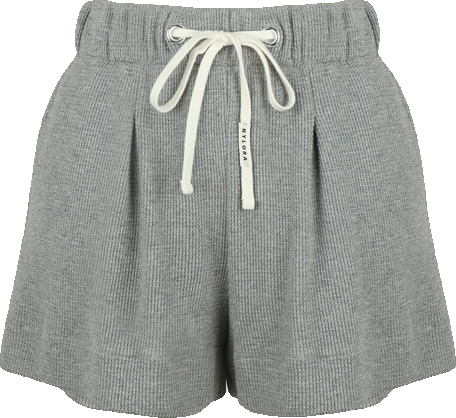

In [24]:
segmented_frame_masks = segment(image_source, sam_predictor, boxes=boxes)
annotated_frame_with_mask = draw_mask(segmented_frame_masks[0][0], annotated_frame)
masked_region_only = apply_mask_to_image(image_source, segmented_frame_masks[0][0])
Image.fromarray(masked_region_only)